# Exploratory Data Analysis (EDA)
## Regensburg Pediatric Appendicitis Dataset

**Contexte :** Ce notebook explore le dataset UCI #938 utilisé pour développer un outil d'aide au diagnostic de l'appendicite pédiatrique.

**Objectifs de l'EDA :**
1. Comprendre la structure et les caractéristiques des données
2. Détecter et traiter les valeurs manquantes
3. Analyser l'équilibre des classes
4. Identifier et gérer les outliers
5. Analyser les corrélations entre features
6. Optimiser la mémoire utilisée

**Dataset :** https://archive.ics.uci.edu/dataset/938/regensburg+pediatric+appendicitis

---
## 1. Chargement des données

In [1]:
# ============================================================
# IMPORTS
# pandas  : manipulation des DataFrames
# numpy   : calcul numérique
# matplotlib / seaborn : visualisation
# scipy.stats : tests statistiques (Mann-Whitney U, skewness)
# ucimlrepo : téléchargement direct du dataset UCI
# SimpleImputer : imputation des valeurs manquantes (sklearn)
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, gaussian_kde
from sklearn.impute import SimpleImputer
from ucimlrepo import fetch_ucirepo
from IPython.display import display

# Style des graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

# ── Palette harmonisée ───────────────────────────────────────
# Rouge  = appendicite | Vert = sain | Violet = neutre
C_APP    = '#ef4444'
C_SAIN   = '#10b981'
C_NEUTRE = '#6366f1'
C_WARN   = '#f59e0b'

# ── Unités médicales ─────────────────────────────────────────
UNITS = {
    'Age'                   : 'ans',
    'BMI'                   : 'kg/m²',
    'Body_Temperature'      : '°C',
    'WBC_Count'             : '10³/µL',
    'CRP'                   : 'mg/L',
    'Neutrophil_Percentage' : '%',
    'Appendix_Diameter'     : 'mm',
    'Height'                : 'cm',
    'Weight'                : 'kg',
    'RBC_Count'             : '10⁶/µL',
    'Hemoglobin'            : 'g/dL',
    'Thrombocyte_Count'     : '10³/µL',
    'RDW'                   : '%',
}

def label_with_unit(col):
    """Retourne 'Variable (unité)' si l'unité est connue."""
    return f"{col} ({UNITS[col]})" if col in UNITS else col

# ── Répertoire de sauvegarde des figures ─────────────────────
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print('✅ Configuration chargée avec succès.')

✅ Configuration chargée avec succès.


In [2]:
# ============================================================
# Téléchargement du dataset depuis UCI (id=938)
# X : features (variables d'entrée du modèle)
# y : target  (diagnostic à prédire)
# ============================================================
regensburg = fetch_ucirepo(id=938)

X = regensburg.data.features   # DataFrame des features cliniques
y = regensburg.data.targets    # DataFrame du diagnostic

print('=' * 60)
print('RÉSUMÉ DU DATASET')
print('=' * 60)
print(f'Nombre de patients   : {X.shape[0]}')
print(f'Nombre de features   : {X.shape[1]}')
print(f'Nombre de targets    : {y.shape[1]}')
print(f'\nColonnes X : {X.columns.tolist()}')
print(f'\nColonnes y : {y.columns.tolist()}')

RÉSUMÉ DU DATASET
Nombre de patients   : 782
Nombre de features   : 53
Nombre de targets    : 3

Colonnes X : ['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis

In [3]:
# Aperçu des 5 premières lignes
print('APERÇU DES FEATURES (5 premières lignes)')
display(X.head())

print('\nDIAGNOSTICS CORRESPONDANTS')
display(y.head())

APERÇU DES FEATURES (5 premières lignes)


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,Migratory_Pain,Lower_Right_Abd_Pain,Contralateral_Rebound_Tenderness,Coughing_Pain,Nausea,Loss_of_Appetite,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,Neutrophilia,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,US_Performed,Free_Fluids,Appendix_Wall_Layers,Target_Sign,Appendicolith,Perfusion,Perforation,Surrounding_Tissue_Reaction,Appendicular_Abscess,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,4.0,3.0,yes,7.1,no,yes,yes,no,no,yes,37.0,7.7,68.2,NaN,no,5.27,14.8,12.2,254.0,++,+,no,0.0,no,normal,no,yes,no,yes,no,intact,NaN,suspected,NaN,no,yes,no,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,5.0,4.0,no,NaN,yes,yes,yes,no,no,yes,36.9,8.1,64.8,NaN,no,5.26,15.7,12.7,151.0,no,no,no,3.0,yes,normal,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,5.0,3.0,no,NaN,no,yes,yes,no,no,no,36.6,13.2,74.8,NaN,no,3.98,11.4,12.2,300.0,no,no,no,3.0,no,constipation,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,7.0,6.0,no,NaN,yes,yes,no,no,yes,yes,36.0,11.4,63.0,NaN,no,4.64,13.6,13.2,258.0,no,no,no,0.0,yes,normal,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,5.0,6.0,yes,7.0,no,yes,yes,yes,yes,yes,36.9,8.1,44.0,NaN,no,4.44,12.6,13.6,311.0,no,no,no,0.0,no,constipation,no,yes,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN



DIAGNOSTICS CORRESPONDANTS


,Management,Severity,Diagnosis
0,conservative,uncomplicated,appendicitis
1,conservative,uncomplicated,no appendicitis
2,conservative,uncomplicated,no appendicitis
3,conservative,uncomplicated,no appendicitis
4,conservative,uncomplicated,appendicitis


In [4]:
# Types de données et statistiques descriptives
# dtypes   : indique si la colonne est numérique (float/int) ou textuelle (object)
# describe : donne min, max, moyenne, écart-type, quartiles pour chaque colonne numérique
display(X.dtypes)
print('\nSTATISTIQUES DESCRIPTIVES')
display(X.describe())

Age                                 float64
BMI                                 float64
Sex                                  object
Height                              float64
Weight                              float64
Length_of_Stay                      float64
Alvarado_Score                      float64
Paedriatic_Appendicitis_Score       float64
Appendix_on_US                       object
Appendix_Diameter                   float64
Migratory_Pain                       object
Lower_Right_Abd_Pain                 object
Contralateral_Rebound_Tenderness     object
Coughing_Pain                        object
Nausea                               object
Loss_of_Appetite                     object
Body_Temperature                    float64
WBC_Count                           float64
Neutrophil_Percentage               float64
Segmented_Neutrophils               float64
Neutrophilia                         object
RBC_Count                           float64
Hemoglobin                      


STATISTIQUES DESCRIPTIVES


,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000
mean,11.346451,18.907012,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.386900
std,3.529909,4.385331,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433854
min,0.000000,7.830000,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000
25%,9.200000,15.725000,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000
50%,11.440000,18.060000,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000
75%,14.100000,21.180000,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000
max,18.360000,38.160000,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000


---
## 2. Valeurs manquantes

### 2.1 Détection

**Pourquoi c'est important ?**  
Les modèles ML ne peuvent pas traiter des valeurs manquantes (NaN). Il faut les détecter avant tout traitement.

In [5]:
# ============================================================
# DÉTECTION DES VALEURS MANQUANTES
# isnull().sum()  : nombre de NaN par colonne
# / len(X) * 100 : conversion en pourcentage
# ============================================================
missing     = X.isnull().sum()
missing_pct = (missing / len(X)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing,
    'Pourcentage (%)'    : missing_pct.round(1)
}).sort_values('Pourcentage (%)', ascending=False)

cols_with_missing = missing_df[missing_df['Valeurs manquantes'] > 0]

print(f'Colonnes affectées : {len(cols_with_missing)} / {X.shape[1]}')
print(f'Total NaN          : {missing.sum()} cellules\n')
display(cols_with_missing)

Colonnes affectées : 53 / 53
Total NaN          : 13980 cellules



,Valeurs manquantes,Pourcentage (%)
Abscess_Location,769,98.3
Gynecological_Findings,756,96.7
Conglomerate_of_Bowel_Loops,739,94.5
Segmented_Neutrophils,728,93.1
Ileus,722,92.3
Perfusion,719,91.9
Enteritis,716,91.6
Appendicolith,713,91.2
Coprostasis,711,90.9
Perforation,701,89.6


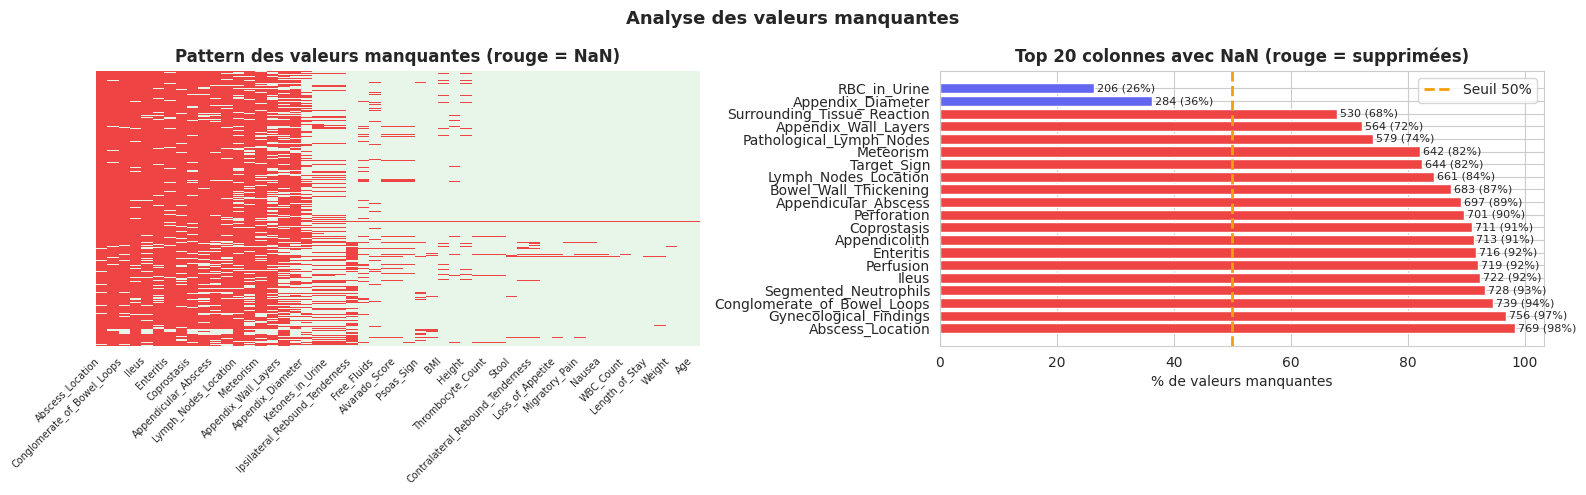

In [7]:
# ── Heatmap des valeurs manquantes ───────────────────────────
# Blanc = valeur présente | Couleur = valeur manquante
# Le pattern des NaN révèle si les manquants sont aléatoires
# ou liés à certains groupes de patients
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap pattern NaN
cols_nan = cols_with_missing.index.tolist()
sns.heatmap(
    X[cols_nan].isnull(), ax=axes[0],
    cbar=False, cmap=['#e8f5e9', '#ef4444'],
    yticklabels=False
)
axes[0].set_title('Pattern des valeurs manquantes (rouge = NaN)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=7)

# Barplot top 20
top20 = cols_with_missing.head(20)
colors_bar = [C_APP if v > 50 else C_NEUTRE for v in top20['Pourcentage (%)']]
axes[1].barh(top20.index, top20['Pourcentage (%)'], color=colors_bar, edgecolor='white')
axes[1].axvline(50, color=C_WARN, linestyle='--', linewidth=2, label='Seuil 50%')
axes[1].set_xlabel('% de valeurs manquantes')
axes[1].set_title('Top 20 colonnes avec NaN (rouge = supprimées)', fontweight='bold')
axes[1].legend()
for i, (val, pct) in enumerate(zip(top20['Valeurs manquantes'], top20['Pourcentage (%)'])):
    axes[1].text(pct + 0.5, i, f'{val} ({pct:.0f}%)', va='center', fontsize=8)

plt.suptitle('Analyse des valeurs manquantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Traitement des valeurs manquantes

Le traitement des valeurs manquantes s'effectue en plusieurs étapes:

.Etape1: 
  Suppression des colonnes avec une proportion de valeurs manquantes supérieure à un seuil de 50%. 
Pourquoi?
   Un feature avec un fort taux de valeurs manquantes n'apporte pas d'information fiable dans la prédiction de la variable cible. La garder pourrait introduire un biais dans notre modèle.
  
.Etape 2:

  Variable numérique: Amputation par la médiane:
      On remplace ces valeurs manquantes par la médiane des valeurs présentes.
      
  Variable catégorielle: Amputation par la mode: 
     On remplace les valeurs manquantes par la classe la plus représentée, le mode. C'est une approche justifiée dans la mesure où cela permet de rester neutre.

In [8]:
# ============================================================
# TRAITEMENT — ÉTAPE 1 : suppression colonnes > 50% NaN
#
# Une colonne à 98% NaN (ex. Abscess_Location) n'apporte
# aucune information statistiquement exploitable
# ============================================================
threshold      = 0.5
cols_to_remove = [col for col in X.columns if X[col].isnull().mean() > threshold]

X_clean = X.copy()
X_clean = X_clean.drop(columns=cols_to_remove)

print(f'Colonnes supprimées (> 50% NaN) : {len(cols_to_remove)}')
print(f'  → {cols_to_remove}')
print(f'Dimensions après suppression    : {X_clean.shape}')

Colonnes supprimées (> 50% NaN) : 18
  → ['Segmented_Neutrophils', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Coprostasis', 'Meteorism', 'Enteritis', 'Gynecological_Findings']
Dimensions après suppression    : (782, 35)


In [9]:
# ============================================================
# TRAITEMENT — ÉTAPES: imputation
# Médiane (numériques) : robuste aux outliers — une valeur
# extrême de CRP=400 n'influence pas la médiane
#
# Mode (catégorielles) : valeur la plus fréquente = estimateur
# le plus neutre pour les variables yes/no
# ============================================================
num_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_clean.select_dtypes(exclude=[np.number]).columns.tolist()

imputer_num = SimpleImputer(strategy='median')
X_clean[num_cols] = imputer_num.fit_transform(X_clean[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_clean[cat_cols] = imputer_cat.fit_transform(X_clean[cat_cols])

nan_residuel = X_clean.isnull().sum().sum()
print(f'NaN résiduels après imputation  : {nan_residuel} ✅')
print(f'Variables numériques imputées   : {len(num_cols)}')
print(f'Variables catégorielles imputées: {len(cat_cols)}')

NaN résiduels après imputation  : 0 ✅
Variables numériques imputées   : 16
Variables catégorielles imputées: 19


### 2.3 Approche avancée — Imputation par régression linéaire

**Limite de l'imputation par la médiane :**
La médiane utilise uniquement la distribution marginale d'une variable,
en ignorant totalement le profil du patient.

> **Exemple médical :** si un patient a `WBC_Count = 15 000`
> et que `Neutrophil_Percentage` lui est corrélé à r = 0.85,
> prédire `Neutrophil_%` par régression donne une valeur qui
> **respecte ce lien biologique**, bien plus réaliste que la médiane globale.

**Algorithme (implémenté dans `src/data_processing.py`) :**

Pour chaque paire (A, B) avec |r| ≥ 0.80 :
1. Si A a des NaN et B est connu → régression `A ~ B` sur les lignes complètes → prédiction des NaN de A
2. Si B a des NaN et A est connu → régression `B ~ A`, même logique
3. Si A et B sont simultanément NaN → impossible → traité par la médiane (fallback)

Les paires sont traitées par **corrélation décroissante** : une valeur
prédite par r = 0.95 devient elle-même disponible pour aider une
prédiction suivante.

> **Note :** Cette méthode avancée est utilisée dans le pipeline de production
> `src/data_processing.py`. Dans ce notebook, on la **démontre sur les données brutes**
> avant imputation pour illustrer son fonctionnement.

 

In [10]:
# ============================================================
# DÉMONSTRATION — Imputation par régression linéaire
# (approche avancée de src/data_processing.py)
#
# On repart des données BRUTES (X avec NaN) pour montrer
# comment la régression prédit les valeurs manquantes
# en exploitant les corrélations biologiques entre variables
#
# LinearRegression : ajuste y = a*x + b sur les lignes
#   complètes, puis prédit les NaN de y à partir de x connu
# ============================================================
from sklearn.linear_model import LinearRegression

CORR_THRESHOLD = 0.80   # seuil de corrélation pour imputation

# ── Données brutes avec NaN (avant toute imputation) ─────────
X_raw = X.drop(columns=cols_to_remove).copy()   # colonnes >50% NaN déjà supprimées
num_raw = X_raw.select_dtypes(include=[np.number]).columns.tolist()

# ── Matrice de corrélation (calculée sur lignes complètes) ───
corr_raw = X_raw[num_raw].corr().abs()

# ── Identifier les paires fortement corrélées ────────────────
pairs = []
for i, col_a in enumerate(num_raw):
    for col_b in num_raw[i+1:]:
        r = corr_raw.loc[col_a, col_b]
        if r >= CORR_THRESHOLD:
            pairs.append((col_a, col_b, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['Variable A', 'Variable B', 'r'])\
             .sort_values('r', ascending=False)

print(f'Paires identifiées (|r| ≥ {CORR_THRESHOLD}) : {len(pairs_df)}')
display(pairs_df)

Paires identifiées (|r| ≥ 0.8) : 4


,Variable A,Variable B,r
0,Age,Height,0.865
1,BMI,Weight,0.859
3,Alvarado_Score,Paedriatic_Appendicitis_Score,0.832
2,Height,Weight,0.830


In [11]:
# ── Démonstration sur une paire : visualisation avant/après ──
# On choisit la paire avec le r le plus élevé pour la démo
if len(pairs_df) > 0:
    col_a = pairs_df.iloc[0]['Variable A']
    col_b = pairs_df.iloc[0]['Variable B']
    r_val = pairs_df.iloc[0]['r']

    # Lignes d'entraînement : les deux colonnes connues
    train_mask   = X_raw[col_a].notna() & X_raw[col_b].notna()
    # Lignes à prédire : col_a manquant, col_b connu
    predict_mask = X_raw[col_a].isna() & X_raw[col_b].notna()

    print(f'Paire démonstration : {col_a} ~ {col_b} (r={r_val})')
    print(f'  Lignes entraînement : {train_mask.sum()}')
    print(f'  NaN à prédire       : {predict_mask.sum()}')

    if train_mask.sum() >= 5 and predict_mask.sum() > 0:
        # Ajustement de la régression
        reg = LinearRegression()
        reg.fit(X_raw.loc[train_mask, [col_b]],
                X_raw.loc[train_mask,  col_a])

        valeurs_predites = reg.predict(X_raw.loc[predict_mask, [col_b]])

        print(f'\n  Régression : {col_a} = {reg.coef_[0]:.4f} × {col_b} + {reg.intercept_:.4f}')
        print(f'  R² (qualité de la régression) : {reg.score(X_raw.loc[train_mask, [col_b]], X_raw.loc[train_mask, col_a]):.3f}')
        print(f'\n  Exemples de valeurs prédites :')
        print(f'  {valeurs_predites[:5].round(2)}')

        # ── Visualisation : nuage de points + droite de régression ──
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # Nuage entraînement + droite
        x_range = np.linspace(X_raw.loc[train_mask, col_b].min(),
                               X_raw.loc[train_mask, col_b].max(), 100)
        axes[0].scatter(X_raw.loc[train_mask, col_b],
                        X_raw.loc[train_mask, col_a],
                        color=C_NEUTRE, alpha=0.5, s=20, label='Données complètes')
        axes[0].plot(x_range, reg.predict(x_range.reshape(-1,1)),
                     color=C_APP, linewidth=2.5, label=f'Régression (R²={reg.score(X_raw.loc[train_mask, [col_b]], X_raw.loc[train_mask, col_a]):.2f})')
        axes[0].set_xlabel(label_with_unit(col_b))
        axes[0].set_ylabel(label_with_unit(col_a))
        axes[0].set_title(f'Régression : {col_a} ~ {col_b}\nr={r_val}', fontweight='bold')
        axes[0].legend()

        # Distribution avant/après imputation
        axes[1].hist(X_raw.loc[train_mask, col_a], bins=25,
                     color=C_NEUTRE, alpha=0.6, density=True,
                     label='Valeurs originales')
        axes[1].hist(valeurs_predites, bins=15,
                     color=C_SAIN, alpha=0.7, density=True,
                     label=f'Valeurs prédites (n={len(valeurs_predites)})')
        axes[1].set_xlabel(label_with_unit(col_a))
        axes[1].set_ylabel('Densité')
        axes[1].set_title(f'Distribution des valeurs imputées\nvs valeurs originales', fontweight='bold')
        axes[1].legend()

        plt.suptitle(
            f'Imputation par régression — {col_a} prédit à partir de {col_b}',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, 'imputation_regression.png'), dpi=150, bbox_inches='tight')
        plt.show()

    else:
        print('  ⚠️ Pas assez de données pour la démonstration sur cette paire.')
else:
    print('Aucune paire avec |r| ≥ 0.80 trouvée dans les données brutes.')

Paire démonstration : Age ~ Height (r=0.865)
  Lignes entraînement : 756
  NaN à prédire       : 0
  ⚠️ Pas assez de données pour la démonstration sur cette paire.


On part à la recherche d'une paire de variables pouvant nous permettre de faire notre démonstration. 

Paire démonstration : Height ~ Age (r=0.865)
  Lignes entraînement : 756
  NaN à prédire       : 25

  Régression : Height = 4.8515 × Age + 92.9893
  R²         : 0.749
  Exemples   : [127.24 179.44 148.3  120.69 161.64]


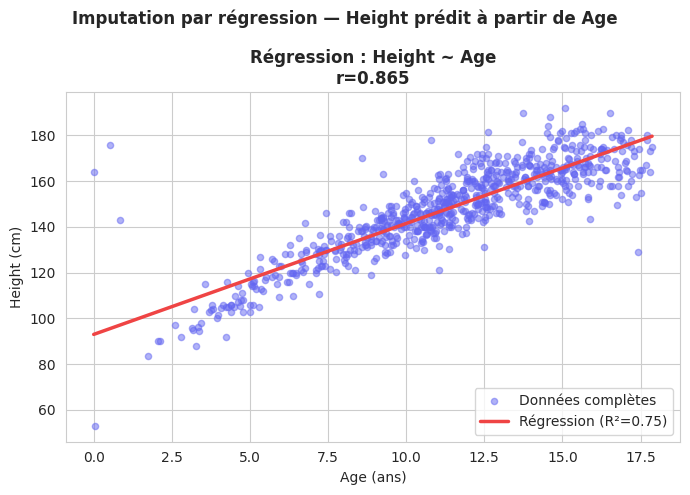

In [12]:
# ── Trouver une paire valide pour la démonstration ───────────
demo_found = False

for _, row in pairs_df.iterrows():
    col_a = row['Variable A']
    col_b = row['Variable B']
    r_val = row['r']

    # Essayer col_a manquant / col_b connu
    for target_var, predictor_var in [(col_a, col_b), (col_b, col_a)]:
        train_mask   = X_raw[target_var].notna() & X_raw[predictor_var].notna()
        predict_mask = X_raw[target_var].isna()  & X_raw[predictor_var].notna()

        if train_mask.sum() >= 5 and predict_mask.sum() > 0:
            demo_found = True
            break
    if demo_found:
        break

if demo_found:
    print(f'Paire démonstration : {target_var} ~ {predictor_var} (r={r_val})')
    print(f'  Lignes entraînement : {train_mask.sum()}')
    print(f'  NaN à prédire       : {predict_mask.sum()}')

    reg = LinearRegression()
    reg.fit(X_raw.loc[train_mask, [predictor_var]],
            X_raw.loc[train_mask,  target_var])

    valeurs_predites = reg.predict(X_raw.loc[predict_mask, [predictor_var]])
    r2 = reg.score(X_raw.loc[train_mask, [predictor_var]],
                   X_raw.loc[train_mask,  target_var])

    print(f'\n  Régression : {target_var} = {reg.coef_[0]:.4f} × {predictor_var} + {reg.intercept_:.4f}')
    print(f'  R²         : {r2:.3f}')
    print(f'  Exemples   : {valeurs_predites[:5].round(2)}')

    # ── Visualisation ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))

    x_range = np.linspace(X_raw.loc[train_mask, predictor_var].min(),
                           X_raw.loc[train_mask, predictor_var].max(), 100)
    ax.scatter(X_raw.loc[train_mask, predictor_var],
                    X_raw.loc[train_mask, target_var],
                    color=C_NEUTRE, alpha=0.5, s=20, label='Données complètes')
    ax.plot(x_range, reg.predict(x_range.reshape(-1,1)),
                 color=C_APP, linewidth=2.5, label=f'Régression (R²={r2:.2f})')
    ax.set_xlabel(label_with_unit(predictor_var))
    ax.set_ylabel(label_with_unit(target_var))
    ax.set_title(f'Régression : {target_var} ~ {predictor_var}\nr={r_val}',
                      fontweight='bold')
    ax.legend()

    plt.suptitle(
        f'Imputation par régression — {target_var} prédit à partir de {predictor_var}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'imputation_regression.png'), dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('ℹ️ Aucune paire avec des NaN à imputer — les données brutes sont trop complètes.')
    print('   La méthode reste active dans data_processing.py pour les cas réels.')


Cette visualisation justifie bien le choix d'une regression linéaire pour la prédiction des valeurs manquantes de la taille à partir de l'âge. Nous avons prédire 25 valeurs manquantes de la taille à partir de l'âge. Cela nous permet d'obenir les valeurs manquantes du BMI que nous allons utiliser pour la prédiction de notre variable cible.

---
## 3. Équilibre des classes (Unbalanced Class)

**Pourquoi c'est important ?**  
Si 90% des patients ont une appendicite et 10% non, un modèle qui prédit toujours "appendicite" aura 90% de précision sans rien apprendre. Il faut vérifier que les classes sont équilibrées.
On considère les classes comme déséquilibrées lorsque le rapport le max et le min des décomptes des classes est supérieur à un certain seuil. Ce threshold valant 1.5 est une convention communement admise en ML; une valeur de laquelle le déséquilibre est assez faible pour biaser significativement le modèle.
Bien sûr, cette considération n'est pas absolue. Elle pourrait être ajustée à des valeurs comme 2.0 voir 3.0. Mais dans un contexte médical, il est faut en toute rigueur être stricte parce qu'une erreur de diagnostique peut avoir de sévères répercutions.

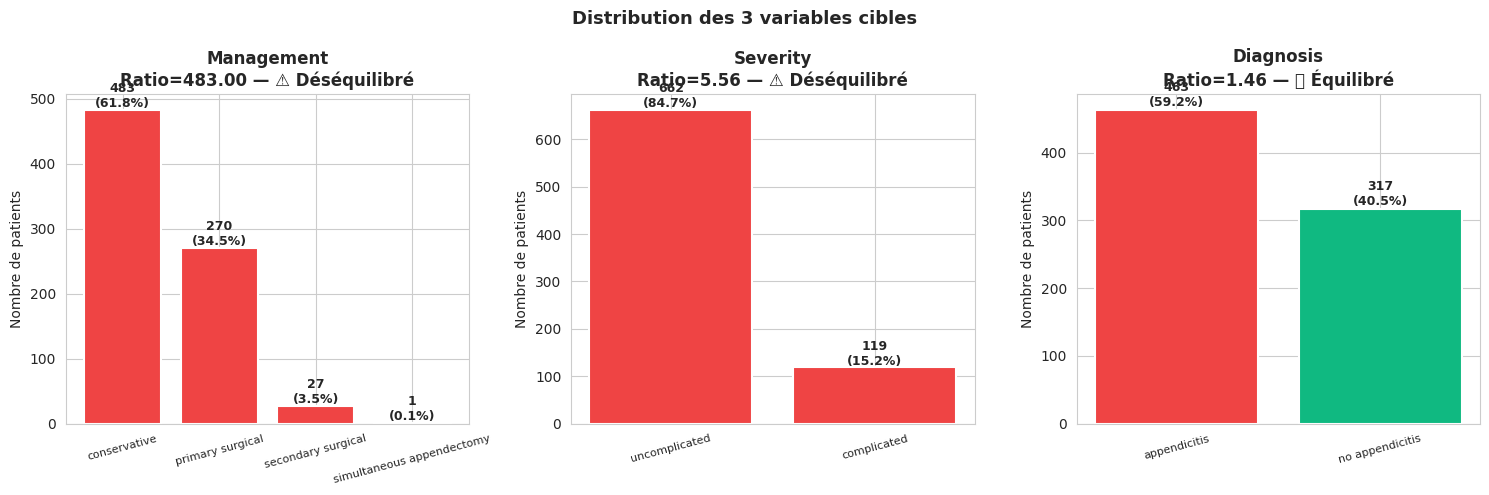


DÉCISIONS PAR VARIABLE CIBLE
  Management                          ratio=483.00 → class_weight='balanced'
  Severity                            ratio=5.56 → class_weight='balanced'
  Diagnosis                           ratio=1.46 → standard

  ➤ Modèle entraîné sur : Diagnosis


In [13]:
# ============================================================
# ANALYSE DE L'ÉQUILIBRE DES 3 VARIABLES CIBLES
# On analyse toutes les cibles en boucle pour ne pas
# répéter le code — plus maintenable et extensible
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, target_col in enumerate(y.columns):
    class_counts = y[target_col].value_counts()
    ratio        = class_counts.max() / class_counts.min()
    balanced     = ratio < 1.5
    decision     = '✅ Équilibré' if balanced else '⚠️ Déséquilibré'

    colors_bar = [C_SAIN if 'no' in str(l).lower() else C_APP
                  for l in class_counts.index]

    axes[i].bar(range(len(class_counts)), class_counts.values,
                color=colors_bar, edgecolor='white', linewidth=1.5)
    axes[i].set_xticks(range(len(class_counts)))
    axes[i].set_xticklabels(class_counts.index, rotation=15, fontsize=8)
    axes[i].set_title(f'{target_col}\nRatio={ratio:.2f} — {decision}', fontweight='bold')
    axes[i].set_ylabel('Nombre de patients')

    for j, v in enumerate(class_counts.values):
        pct = v / len(y) * 100
        axes[i].text(j, v + 5, f'{v}\n({pct:.1f}%)',
                     ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Distribution des 3 variables cibles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Résumé des décisions
print('\n' + '=' * 55)
print('DÉCISIONS PAR VARIABLE CIBLE')
print('=' * 55)
for target_col in y.columns:
    cc     = y[target_col].value_counts()
    ratio  = cc.max() / cc.min()
    dec    = "standard" if ratio < 1.5 else "class_weight='balanced'"
    print(f'  {target_col:<35} ratio={ratio:.2f} → {dec}')
print('\n  ➤ Modèle entraîné sur : Diagnosis')

# ratio pour les conclusions
ratio = y['Diagnosis'].value_counts().max() / y['Diagnosis'].value_counts().min()


DÉCISION FINALE

Target retenue pour le modèle : Diagnosis
Raison : question médicale principale + dataset quasi équilibré (~59/41)
         → métriques standard (accuracy, precision, recall, F1, ROC-AUC) sont fiables

Targets écartées :
  - Severity   : déséquilibré → nécessite class_weight='balanced'
  - Management : très déséquilibré (4 classes) → modèle multiclasse
                 hors de la porté du projet actuel


Pour optimiser la performance du modèle SVM nous pouvons procéder à l'utilisation du 'weight_balanced'. Ce modèle contrairement aux autres que nous voulons utiliser est très sensible au déséquilibre des classes.

---
## 4. Détection et traitement des Outliers
  
Pour détecter les outliers, nous choisissons non seulement de procéder à une visualisation de la distribution de chaque variable numérique (historigramme + courbe KDE) mais aussi et surtout à la détermination du coefficient d'asymétrie, le skewness de chacune d'elle afin de choisir la méthode de traitement la plus appropriée. Cela constitue des indicateurs clé permettant d'avoir une idée des méthodes existantes dans la littérature auxquelles nous pourrons faire appel pour un traitement efficace et convenable à chaque variable. Nous optons pour une approche analytique consistant à faire parler les données.


Variables normales    (Z-score) : 3
  → ['Age', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score']

Variables asymétriques (IQR)   : 13
  → ['BMI', 'Height', 'Weight', 'Length_of_Stay', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


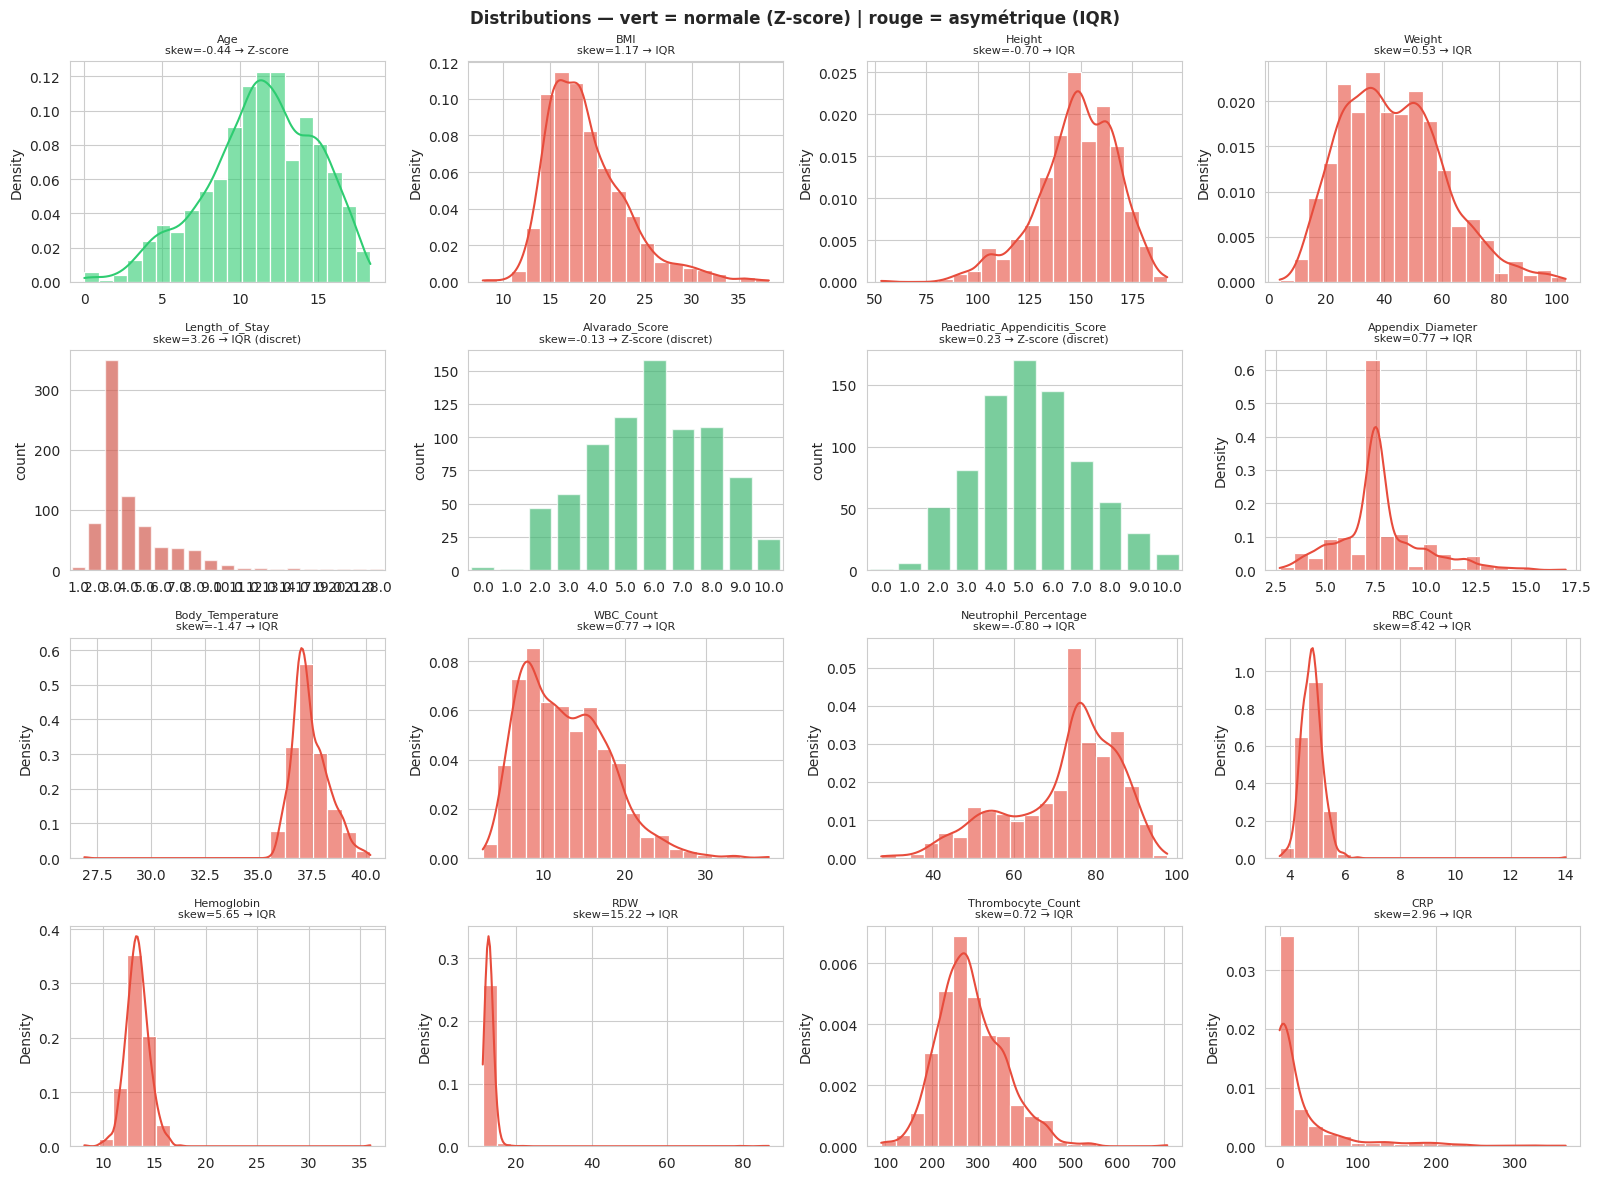

In [14]:

# ============================================================
# VISUALISATION DES DISTRIBUTIONS POUR CHOISIR LA MÉTHODE
# 
# Objectif : déterminer pour chaque variable numérique
# si sa distribution est normale (→ Z-score) 
# ou asymétrique (→ IQR)
#
# On utilise deux indicateurs :
#   - Histogramme + courbe KDE : visualisation de la forme
#   - Skewness (asymétrie)     : mesure numérique
#       |skewness| < 0.5  → distribution symétrique  → Z-score
#       |skewness| >= 0.5 → distribution asymétrique → IQR
# ============================================================

num_cols_clean = X_clean.select_dtypes(include=[np.number]).columns.tolist()
skewness       = X_clean[num_cols_clean].skew()

normal_cols = [col for col in num_cols_clean if abs(skewness[col]) < 0.5]
skewed_cols = [col for col in num_cols_clean if abs(skewness[col]) >= 0.5]

print(f'Variables normales    (Z-score) : {len(normal_cols)}')
print(f'  → {normal_cols}')
print(f'\nVariables asymétriques (IQR)   : {len(skewed_cols)}')
print(f'  → {skewed_cols}')
# ============================================================
# ÉTAPE 2 — Visualisation des distributions
#
# sns.histplot avec kde=True et bw_adjust=0.8 :
#   bw_adjust = 0.8 → lissage modéré (ni trop bruité à 0.5
#   ni trop lissé à 1.0) — courbe KDE fidèle à l'histogramme
#
# Variables discrètes (n_unique ≤ 20) → countplot
# Variables continues (n_unique > 20) → histplot + KDE
#
# Couleurs : vert = normale (Z-score) | rouge = asymétrique (IQR)
# ============================================================
cols_per_row = 4
n_rows = (len(num_cols_clean) + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols_clean):
    sk       = skewness[col]
    color    = '#2ecc71' if abs(sk) < 0.5 else '#e74c3c'
    method   = 'Z-score' if abs(sk) < 0.5 else 'IQR'
    n_unique = X_clean[col].nunique()

    if n_unique <= 20:
        # Variable discrète — barres exactes par valeur entière
        sns.countplot(x=X_clean[col], color=color, alpha=0.7, ax=axes[i])
        axes[i].set_title(f'{col}\nskew={sk:.2f} → {method} (discret)', fontsize=8)
    else:
        # Variable continue — histogramme + KDE ajusté
        sns.histplot(
            X_clean[col], bins=20, color=color, alpha=0.6,
            kde=True, stat='density',
            kde_kws={'bw_adjust': 0.8},
            ax=axes[i]
        )
        axes[i].set_title(f'{col}\nskew={sk:.2f} → {method}', fontsize=8)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Distributions — vert = normale (Z-score) | rouge = asymétrique (IQR)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


4.1 TRAITEMENT DES OUTLIERS — MÉTHODE ADAPTÉE PAR VARIABLE

 Suite logique de l'analyse des distributions :
   - Variables normales     (|skewness| < 0.5) → Z-score + capping
   - Variables asymétriques (|skewness| >= 0.5) → IQR + capping

Traitement choisi : Capping (Winsorization) dans les deux cas.
 On remplace les valeurs extrêmes par les bornes
au lieu de les supprimer — aucun patient n'est perdu


In [15]:


# ============================================================
# ÉTAPE 3 — Capping adaptatif (Winsorization)
#
# Pour chaque colonne numérique :
#   Normale     → bornes Z-score : mean ± 3*std
#   Asymétrique → bornes IQR     : Q1−1.5*IQR / Q3+1.5*IQR
#
# clip(lower, upper) : valeurs hors bornes → ramenées à la borne
#   Valeur < lower → lower
#   Valeur > upper → upper
#   Valeur dans les bornes → inchangée
# ============================================================
X_no_outliers = X_clean.copy()
report = []

for col in num_cols_clean:
    if col in normal_cols:
        mean, std    = X_no_outliers[col].mean(), X_no_outliers[col].std()
        lower, upper = mean - 3 * std, mean + 3 * std
        method       = 'Z-score'
    else:
        Q1, Q3       = X_no_outliers[col].quantile([0.25, 0.75])
        IQR          = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        method       = 'IQR'

    n_out = ((X_no_outliers[col] < lower) | (X_no_outliers[col] > upper)).sum()
    X_no_outliers[col] = X_no_outliers[col].clip(lower, upper)

    if n_out > 0:
        report.append({
            'Variable'   : col,
            'Méthode'    : method,
            'N outliers' : n_out,
            '% outliers' : round(n_out / len(X_clean) * 100, 2)
        })

report_df = pd.DataFrame(report).sort_values('% outliers', ascending=False)

print(f'Variables affectées : {len(report_df)}')
print(f'Patients supprimés  : 0 ✅\n')
display(report_df)

Variables affectées : 14
Patients supprimés  : 0 ✅



,Variable,Méthode,N outliers,% outliers
5,Appendix_Diameter,IQR,217,27.75
13,CRP,IQR,91,11.64
4,Length_of_Stay,IQR,44,5.63
1,BMI,IQR,30,3.84
10,Hemoglobin,IQR,26,3.32
11,RDW,IQR,23,2.94
2,Height,IQR,15,1.92
9,RBC_Count,IQR,15,1.92
6,Body_Temperature,IQR,12,1.53
12,Thrombocyte_Count,IQR,9,1.15


# 4.2 Rapport de traitement des outliers


 4.3 VISUALISATION AVANT / APRÈS CAPPING
 
 On compare les boxplots pour vérifier que le traitement
 a bien réduit les valeurs extrêmes

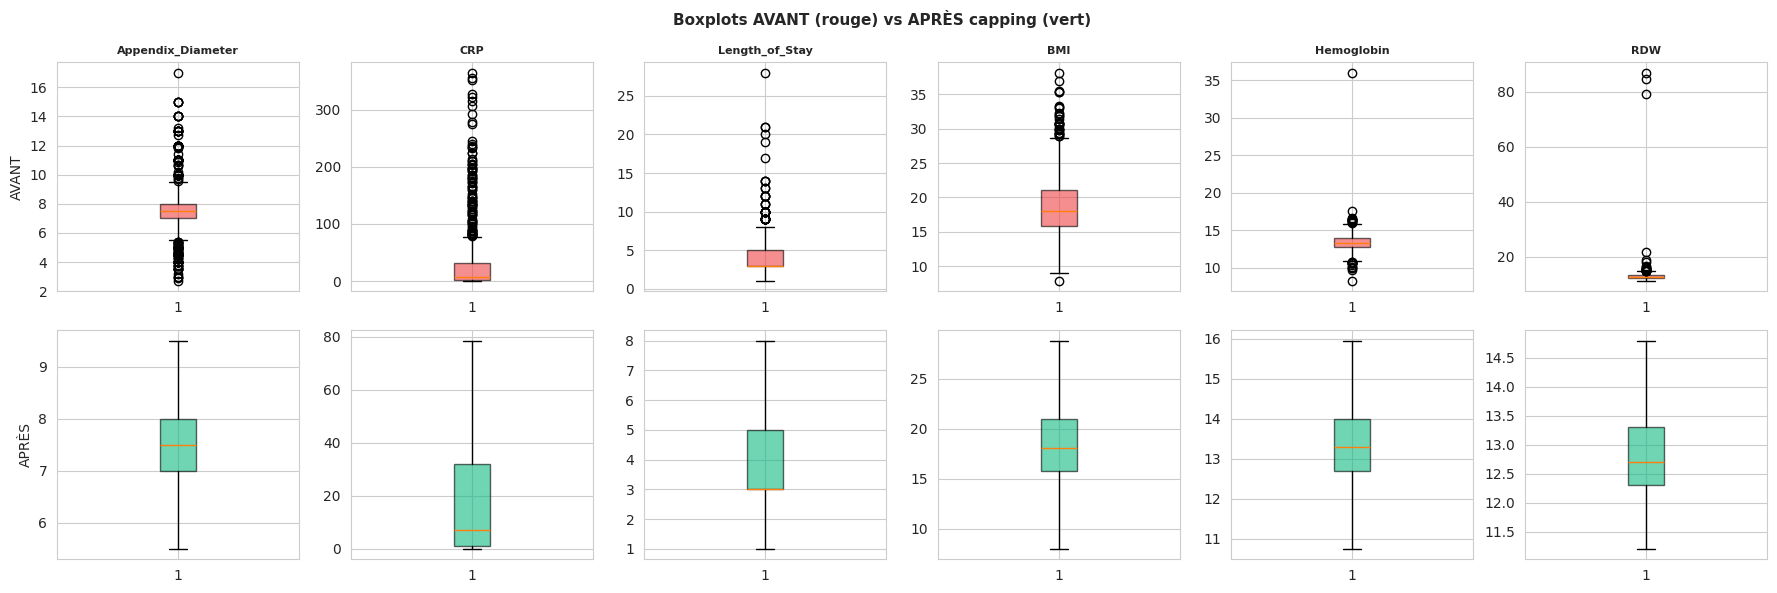

In [16]:
# ============================================================
# ÉTAPE 4 — Visualisation AVANT / APRÈS capping
#
# On affiche les 6 variables les plus affectées (triées par
# % outliers décroissant dans report_df)
#
# Ligne rouge  (AVANT) : points isolés = outliers visibles
# Ligne verte  (APRÈS) : plus de points isolés hors moustaches
# ============================================================
top_cols = report_df['Variable'].tolist()[:6]

fig, axes = plt.subplots(2, len(top_cols), figsize=(len(top_cols) * 3, 6))

for i, col in enumerate(top_cols):
    axes[0, i].boxplot(X_clean[col], patch_artist=True,
                       boxprops=dict(facecolor=C_APP, alpha=0.6))
    axes[0, i].set_title(col, fontsize=8, fontweight='bold')
    axes[0, i].set_ylabel('AVANT' if i == 0 else '')

    axes[1, i].boxplot(X_no_outliers[col], patch_artist=True,
                       boxprops=dict(facecolor=C_SAIN, alpha=0.6))
    axes[1, i].set_ylabel('APRÈS' if i == 0 else '')

plt.suptitle('Boxplots AVANT (rouge) vs APRÈS capping (vert)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'boxplots_by_diagnosis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Corrélation entre les features

**Pourquoi analyser les corrélations ?**  
Si deux features sont très corrélées (ex: r > 0.8), elles apportent la même information au modèle. Garder les deux crée de la redondance et peut nuire à certains modèles (ex: régression logistique, SVM).

**Seuil choisi : |r| > 0.8**  
Au-delà de 0.8, on considère la corrélation forte. On supprimera une des deux features.

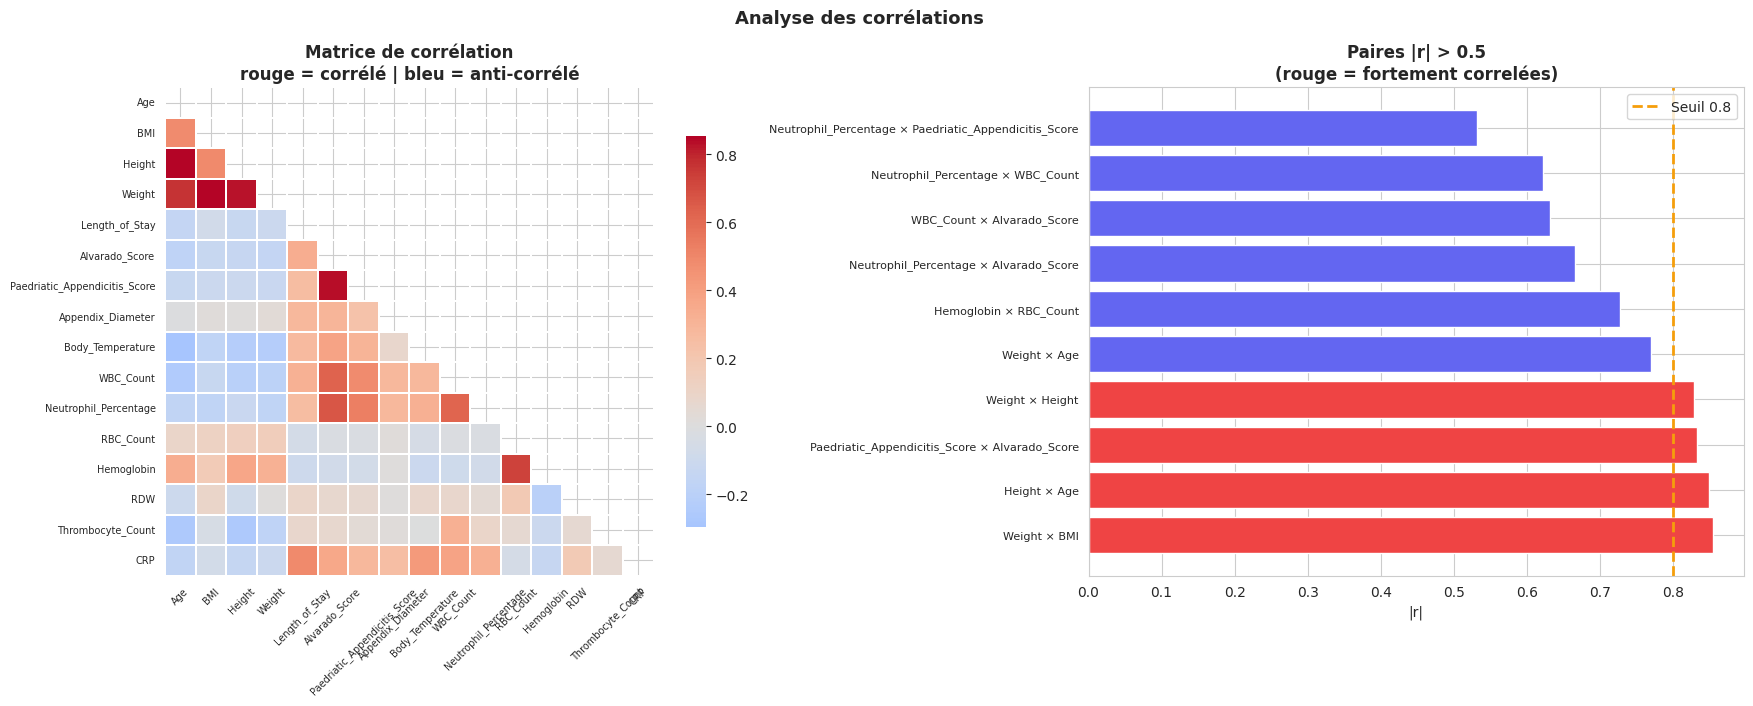

In [17]:
# ============================================================
# MATRICE DE CORRÉLATION DE PEARSON
#
# mask (triangle supérieur) : la matrice est symétrique —
# r(A,B) = r(B,A) → on n'affiche que le triangle inférieur
# pour éviter la redondance visuelle
# ============================================================
corr_matrix = X_no_outliers.select_dtypes(include=[np.number]).corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap complète
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='coolwarm', center=0,
    square=True, linewidths=0.3,
    ax=axes[0], cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matrice de corrélation\nrouge = corrélé | bleu = anti-corrélé',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Barplot paires |r| > 0.5
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            high_corr_pairs.append({
                'Feature 1'     : corr_matrix.columns[i],
                'Feature 2'     : corr_matrix.columns[j],
                'Corrélation r' : round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Corrélation r', ascending=False)

if len(high_corr_df) > 0:
    high_corr_df['Paire'] = high_corr_df['Feature 1'] + ' × ' + high_corr_df['Feature 2']
    colors_c = [C_APP if abs(r) > 0.8 else C_NEUTRE for r in high_corr_df['Corrélation r']]
    axes[1].barh(high_corr_df['Paire'], high_corr_df['Corrélation r'].abs(),
                 color=colors_c, edgecolor='white')
    axes[1].axvline(0.8, color=C_WARN, linestyle='--', linewidth=2, label='Seuil 0.8')
    axes[1].set_xlabel('|r|')
    axes[1].set_title('Paires |r| > 0.5\n(rouge = fortement correlées)', fontweight='bold')
    axes[1].legend()
    axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Analyse des corrélations', fontsize=13, fontweight='bold')
plt.tight_layout()
# Sauvegarde des deux graphiques séparément
axes[0].get_figure().savefig(os.path.join(FIG_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'correlation_pairs.png'), dpi=150, bbox_inches='tight')

In [18]:
# ============================================================
# SUPPRESSION DES FEATURES REDONDANTES
#
# np.triu(..., k=1) : triangle supérieur SANS la diagonale
#   k=1 exclut la diagonale car r(A,A)=1 toujours
#
# Pour chaque colonne : si corrélée > 0.8 avec au moins
# une autre → supprimée
# ============================================================
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
cols_to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
X_final      = X_no_outliers.drop(columns=cols_to_drop)

print(f'Features supprimées ({len(cols_to_drop)}) : {cols_to_drop}')
print(f'Dimensions avant : {X_no_outliers.shape}')
print(f'Dimensions après : {X_final.shape} ✅')

Features supprimées (3) : ['Height', 'Weight', 'Paedriatic_Appendicitis_Score']
Dimensions avant : (782, 35)
Dimensions après : (782, 32) ✅


---
## 6. Tests statistiques — Features discriminantes

Le test **Mann-Whitney U** évalue si une variable se distribue différemment
selon le groupe de diagnostic. C'est un test **non-paramétrique** adapté aux
données médicales car :
- Il ne suppose pas la normalité des distributions
- Il est robuste aux valeurs extrêmes
- Il compare les distributions complètes, pas seulement les moyennes

**Interprétation de la p-value :**
- `p < 0.001` → `***` — différence hautement significative
- `p < 0.01`  → `**`  — très significative
- `p < 0.05`  → `*`   — significative
- `p ≥ 0.05`  → `ns`  — non significative

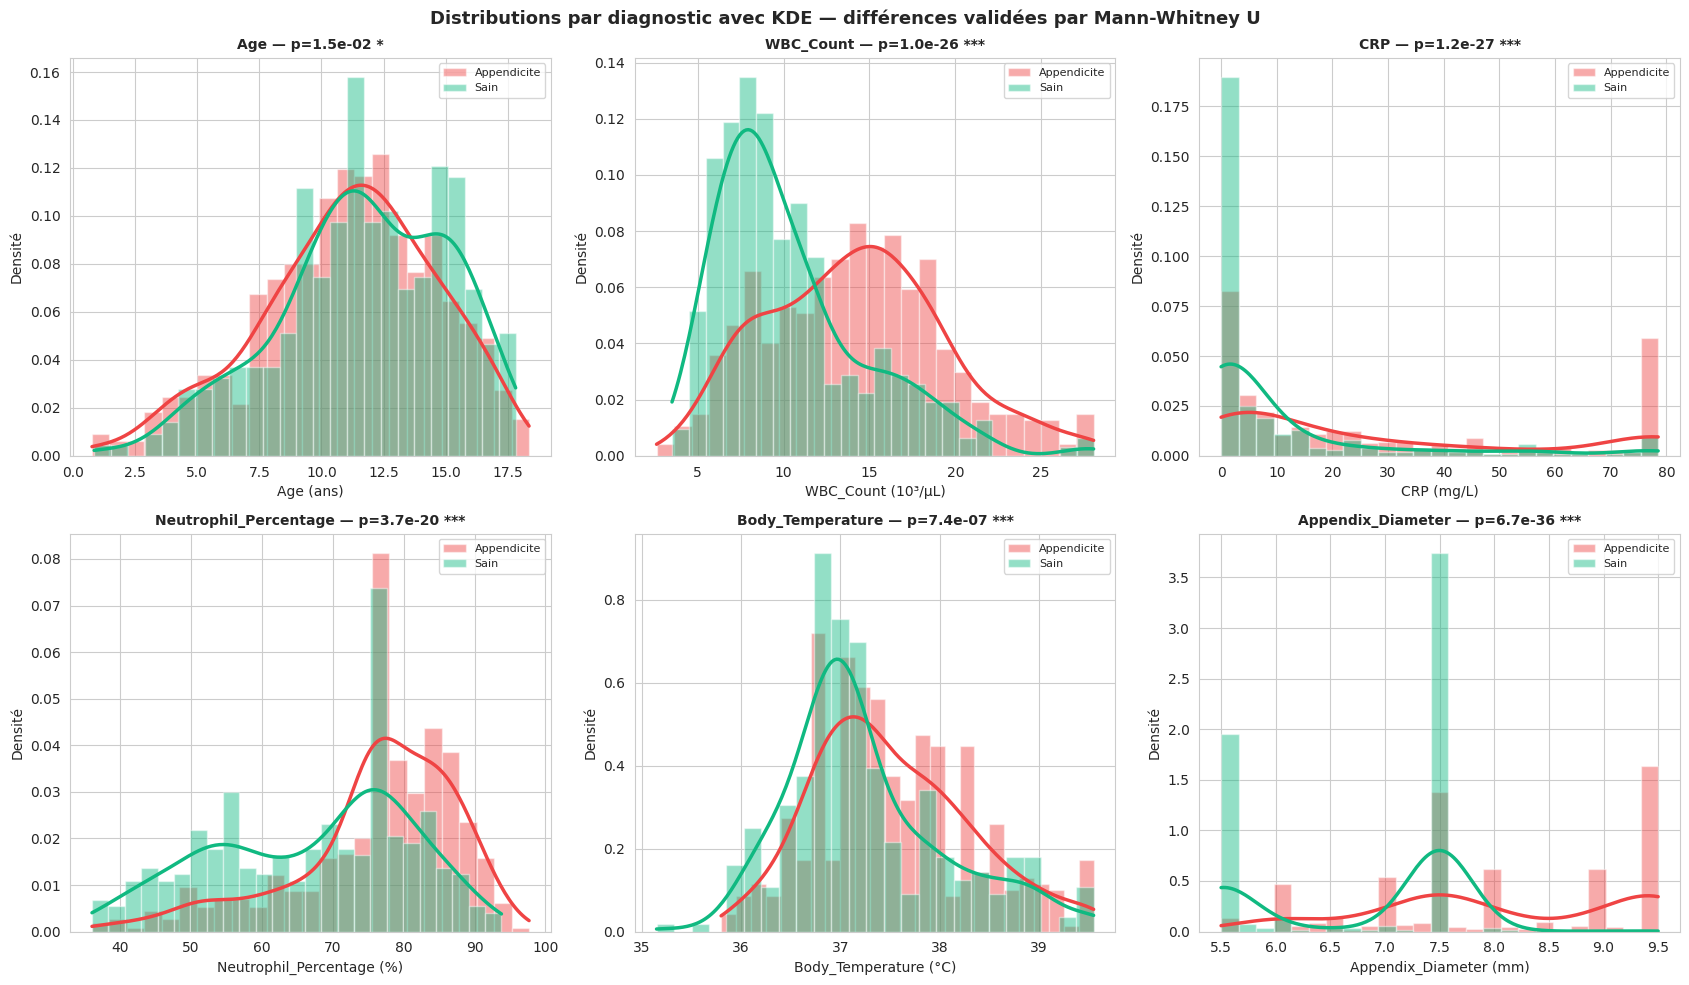

In [19]:
# ============================================================
# DISTRIBUTIONS PAR GROUPE + TEST MANN-WHITNEY U
#
# gaussian_kde : estimation non-paramétrique de la densité
#   par noyau gaussien — courbe lissée calculée directement
#   sur les données sans supposer une forme particulière
#
# On évalue la KDE sur 200 points équidistants entre min et max
# pour obtenir une courbe fluide
# ============================================================
df_plot       = X_final.copy()
df_plot['Diagnosis'] = y['Diagnosis'].values

plot_features = ['Age', 'WBC_Count', 'CRP',
                 'Neutrophil_Percentage', 'Body_Temperature', 'Appendix_Diameter']
plot_features = [f for f in plot_features if f in df_plot.columns]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    grp_app  = df_plot.loc[df_plot['Diagnosis'] == 'appendicitis',    col].dropna()
    grp_sain = df_plot.loc[df_plot['Diagnosis'] == 'no appendicitis', col].dropna()

    for data, lbl, clr in [(grp_app,  'Appendicite', C_APP),
                            (grp_sain, 'Sain',        C_SAIN)]:
        axes[i].hist(data, bins=25, alpha=0.45,
                     label=lbl, color=clr,
                     edgecolor='white', density=True)
        if len(data) > 2:
            xs  = np.linspace(data.min(), data.max(), 200)
            kde = gaussian_kde(data)
            axes[i].plot(xs, kde(xs), color=clr, linewidth=2.5)

    # Test Mann-Whitney U
    if len(grp_app) > 0 and len(grp_sain) > 0:
        _, pval = mannwhitneyu(grp_app, grp_sain, alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        axes[i].set_title(f'{col} — p={pval:.1e} {sig}',
                          fontweight='bold', fontsize=10)

    axes[i].set_xlabel(label_with_unit(col))
    axes[i].set_ylabel('Densité')
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Distributions par diagnostic avec KDE — différences validées par Mann-Whitney U',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distributions_by_diagnosis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Optimisation mémoire

**Pourquoi optimiser la mémoire ?**  
Par défaut, pandas utilise `float64` (8 octets) et `int64` (8 octets). En passant à `float32` (4 octets) et `int32` (4 octets), on divise la mémoire par 2 sans perte de précision significative pour ce type de données médicales.

**Règle appliquée :**
- `float64` → `float32`
- `int64` → `int32`
- `object` avec < 50% valeurs uniques → `category`

In [20]:
# ============================================================
# MÉMOIRE AVANT OPTIMISATION
#
# memory_usage(deep=True) : calcule la mémoire réelle incluant
# les objets Python — sans deep=True, les colonnes 'object'
# sont sous-estimées
# ============================================================
mem_before = X_final.memory_usage(deep=True).sum() / 1024**2
print(f'Mémoire avant optimisation : {mem_before:.4f} MB')
print('\nTypes AVANT :')
print(X_final.dtypes.value_counts())

Mémoire avant optimisation : 0.8115 MB

Types AVANT :
object     19
float64    13
Name: count, dtype: int64


Mémoire avant optimisation : 0.8115 MB
Mémoire après optimisation  : 0.0576 MB
Réduction                   : 92.9% ✅

Types APRÈS :
float32     13
category    13
category     3
category     1
category     1
category     1
Name: count, dtype: int64

Détail par colonne :


,Colonne,Type avant,Type après,KB avant,KB après,Réduction (%)
0,Age,float64,float32,6.24,3.18,49.0
1,BMI,float64,float32,6.24,3.18,49.0
2,Sex,object,category,41.34,1.10,97.3
3,Length_of_Stay,float64,float32,6.24,3.18,49.0
4,Alvarado_Score,float64,float32,6.24,3.18,49.0
5,Appendix_on_US,object,category,39.57,1.10,97.2
6,Appendix_Diameter,float64,float32,6.24,3.18,49.0
7,Migratory_Pain,object,category,39.28,1.10,97.2
8,Lower_Right_Abd_Pain,object,category,39.80,1.10,97.2
9,Contralateral_Rebound_Tenderness,object,category,39.37,1.10,97.2


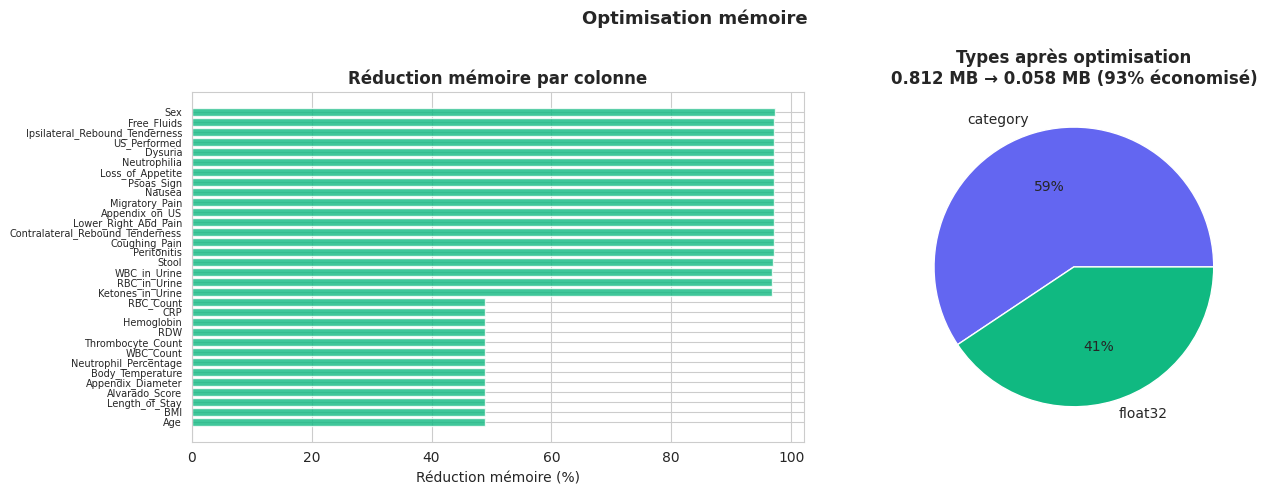

In [21]:
# ============================================================
# OPTIMISATION MÉMOIRE
#
# Seuil 50% pour category : si < 50% de valeurs uniques,
# la colonne stocke de la redondance → category la compresse
# en encodant chaque valeur unique comme un entier
# ============================================================
X_optimized = X_final.copy()
memory_report = []

for col in X_optimized.columns:
    col_type       = X_optimized[col].dtype
    mem_avant      = X_optimized[col].memory_usage(deep=True) / 1024
    old_type       = str(col_type)
    new_type       = old_type

    if col_type == 'float64':
        X_optimized[col] = X_optimized[col].astype('float32')
        new_type = 'float32'
    elif col_type == 'int64':
        X_optimized[col] = X_optimized[col].astype('int32')
        new_type = 'int32'
    elif col_type == 'object':
        n_unique = X_optimized[col].nunique()
        if n_unique / len(X_optimized) < 0.5:
            X_optimized[col] = X_optimized[col].astype('category')
            new_type = 'category'

    mem_apres = X_optimized[col].memory_usage(deep=True) / 1024
    memory_report.append({
        'Colonne'       : col,
        'Type avant'    : old_type,
        'Type après'    : new_type,
        'KB avant'      : round(mem_avant, 2),
        'KB après'      : round(mem_apres, 2),
        'Réduction (%)' : round((1 - mem_apres / mem_avant) * 100, 1)
    })

mem_after = X_optimized.memory_usage(deep=True).sum() / 1024**2
reduction = ((mem_before - mem_after) / mem_before) * 100

print(f'Mémoire avant optimisation : {mem_before:.4f} MB')
print(f'Mémoire après optimisation  : {mem_after:.4f} MB')
print(f'Réduction                   : {reduction:.1f}% ✅')
print('\nTypes APRÈS :')
print(X_optimized.dtypes.value_counts())
print('\nDétail par colonne :')
display(pd.DataFrame(memory_report))

# ── Visualisation de la réduction mémoire ────────────────────
mem_rep_df = pd.DataFrame(memory_report)
mem_rep_df = mem_rep_df[mem_rep_df['Réduction (%)'] > 0].sort_values('Réduction (%)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot réduction par colonne
axes[0].barh(mem_rep_df['Colonne'], mem_rep_df['Réduction (%)'],
             color=C_SAIN, edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Réduction mémoire (%)')
axes[0].set_title('Réduction mémoire par colonne', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=7)

# Camembert avant/après types
type_counts_after = X_optimized.dtypes.astype(str).value_counts()
axes[1].pie(type_counts_after.values,
            labels=type_counts_after.index,
            autopct='%1.0f%%',
            colors=[C_NEUTRE, C_SAIN, C_APP, C_WARN][:len(type_counts_after)])
axes[1].set_title(f'Types après optimisation\n{mem_before:.3f} MB → {mem_after:.3f} MB ({reduction:.0f}% économisé)',
                  fontweight='bold')

plt.suptitle('Optimisation mémoire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'memory_optimization.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Récapitulatif & Conclusions

In [22]:
print('=' * 65)
print('CONCLUSIONS DE L\'EDA — DÉCISIONS PRISES')
print('=' * 65)
print(f'''
1. VALEURS MANQUANTES
   Détectées : {missing.sum()} valeurs sur {X.shape[0] * X.shape[1]} cellules
   Décision  : Imputation médiane (numériques) + mode (catégorielles)
   Résultat  : 0 valeur manquante dans X_clean ✅

2. ÉQUILIBRE DES CLASSES
   Ratio     : {ratio:.2f}
   Décision  : {"Pas de rééchantillonnage nécessaire" if ratio < 1.5 else "Appliquer class_weight='balanced'"}

3. OUTLIERS
   Méthode   : Adaptative — Z-score (normal) | IQR (asymétrique)
   Décision  : Capping (Winsorization) — aucun patient supprimé
   Résultat  : Valeurs extrêmes ramenées aux bornes ✅

4. CORRÉLATION
   Seuil     : |r| > 0.8
   Supprimées: {cols_to_drop}
   Résultat  : {X_final.shape[1]} features conservées ✅

5. TESTS STATISTIQUES (Mann-Whitney U)
   WBC_Count, CRP, Neutrophil_% → p < 0.001 ***
   Appendix_Diameter            → p < 0.001 ***
   Body_Temperature             → significatif *

6. MÉMOIRE
   Avant     : {mem_before:.4f} MB
   Après     : {mem_after:.4f} MB
   Réduction : {reduction:.1f}% ✅

DATASET FINAL PRÊT POUR LE MODÈLE : X_optimized {X_optimized.shape}
''')
print('=' * 65)

CONCLUSIONS DE L'EDA — DÉCISIONS PRISES

1. VALEURS MANQUANTES
   Détectées : 13980 valeurs sur 41446 cellules
   Décision  : Imputation médiane (numériques) + mode (catégorielles)
   Résultat  : 0 valeur manquante dans X_clean ✅

2. ÉQUILIBRE DES CLASSES
   Ratio     : 1.46
   Décision  : Pas de rééchantillonnage nécessaire

3. OUTLIERS
   Méthode   : Adaptative — Z-score (normal) | IQR (asymétrique)
   Décision  : Capping (Winsorization) — aucun patient supprimé
   Résultat  : Valeurs extrêmes ramenées aux bornes ✅

4. CORRÉLATION
   Seuil     : |r| > 0.8
   Supprimées: ['Height', 'Weight', 'Paedriatic_Appendicitis_Score']
   Résultat  : 32 features conservées ✅

5. TESTS STATISTIQUES (Mann-Whitney U)
   WBC_Count, CRP, Neutrophil_% → p < 0.001 ***
   Appendix_Diameter            → p < 0.001 ***
   Body_Temperature             → significatif *

6. MÉMOIRE
   Avant     : 0.8115 MB
   Après     : 0.0576 MB
   Réduction : 92.9% ✅

DATASET FINAL PRÊT POUR LE MODÈLE : X_optimized (782, 32

# 9. Sauvegarde des données

In [23]:
# ============================================================
# SAUVEGARDE DES DONNÉES PRÉPROCESSÉES
#
# X_optimized → data/processed/X_processed.csv
# y           → data/processed/y_processed.csv
#
# index=False : ne pas sauvegarder l'index numérique (inutile)
# exist_ok=True : pas d'erreur si le dossier existe déjà
# ============================================================
processed_dir = os.path.join('..', 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

X_optimized.to_csv(os.path.join(processed_dir, 'X_processed.csv'), index=False)
y.to_csv(os.path.join(processed_dir, 'y_processed.csv'), index=False)

print(f'✅ X_processed.csv sauvegardé : {X_optimized.shape}')
print(f'✅ y_processed.csv sauvegardé : {y.shape}')
print(f'✅ Figures sauvegardées dans  : {os.path.abspath(FIG_DIR)}')

✅ X_processed.csv sauvegardé : (782, 32)
✅ y_processed.csv sauvegardé : (782, 3)
✅ Figures sauvegardées dans  : /home/rudolf/Coding-week-project/reports/figures
